# Heart Disease Prediction

This project focuses on exploring the Heart Disease dataset and building a machine learning model to predict the presence of heart disease.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score




# Exploratory Data Analysis (EDA)

This section focuses on exploring and understanding the Heart Disease dataset before building the machine learning models.

The main objectives of the EDA are to:

* Understand the structure and characteristics of the dataset.
* Check for missing values and duplicate records.
* Analyze the target variable distribution.
* Explore numerical and categorical features.
* Identify invalid values and potential outliers.
* Investigate relationships between features and heart disease.
* Analyze correlations between numerical features.


## Step 1 — Dataset Overview

The Heart Disease dataset is loaded and inspected to understand its size, features, and data types.

The dataset contains **918 observations and 12 columns**.

The target variable is `HeartDisease`, where:

* `0` represents no heart disease.
* `1` represents the presence of heart disease.


In [12]:
df = pd.read_csv("../data/heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


### Inspecting Column Names

The column names are examined to identify the available features and the target variable.


In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

### Inspecting Data Types and Structure

The dataset structure and data types are examined using `df.info()`.

The dataset contains both numerical and categorical features, which will require different types of analysis and preprocessing.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


## Step 2 — Checking Missing Values

Missing values are checked for each column.

Initially, Pandas reports no explicit missing values in the dataset. However, some values may still be invalid even if they are not stored as `NaN`. These cases will be investigated during the EDA.


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## Step 3 — Descriptive Statistics

Descriptive statistics are calculated for the numerical features to understand their ranges, central tendency, and variability.

The results also help identify unusual values that may require further investigation.


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Initial Observations

The numerical features have different ranges and distributions.

One notable observation is that `RestingBP` and `Cholesterol` contain minimum values of `0`, which require further investigation because these values are not realistic clinical measurements.


## Step 4 — Checking Duplicate Records

Duplicate rows are checked to ensure that the dataset does not contain repeated observations.


In [13]:
df.duplicated().sum()

np.int64(0)

The dataset contains **0 duplicate records**, so no rows need to be removed due to duplication.


## Step 5 — Identifying Feature Types

The features are separated into numerical and categorical variables.

This separation is useful because numerical and categorical features require different visualization and analysis techniques.


In [14]:
df.select_dtypes(include="str").columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')

## Step 6 — Target Variable Distribution

The distribution of the target variable `HeartDisease` is analyzed to determine the number and proportion of patients with and without heart disease.

Understanding the target distribution is important before training a classification model.


In [4]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [5]:
df["HeartDisease"].value_counts(normalize=True) * 100

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

### Interpretation

The dataset contains:

* **508 patients (55.34%)** with heart disease.
* **410 patients (44.66%)** without heart disease.

The classes are relatively balanced, with a slightly higher proportion of patients with heart disease.


### Visualization Interpretation

The bar plot visually confirms the distribution of the target variable.

The two classes have relatively similar numbers of observations, with `HeartDisease = 1` being slightly more frequent than `HeartDisease = 0`.

This indicates that the target variable is **relatively balanced**, so there is no severe class imbalance in the dataset.


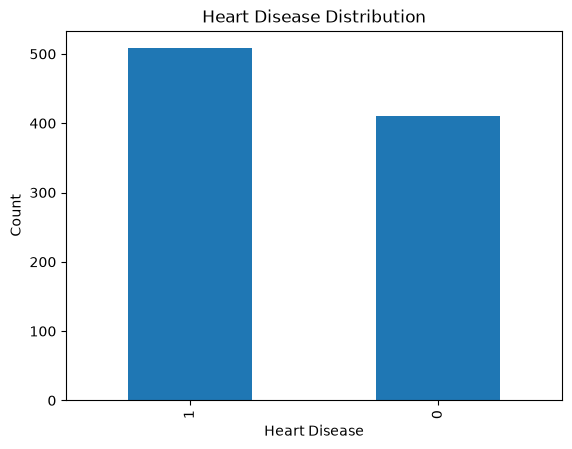

In [10]:
df["HeartDisease"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

### Interpretation

The bar plot shows that the number of patients with and without heart disease is relatively similar. However, the `HeartDisease = 1` category is slightly higher than the `HeartDisease = 0` category.

This confirms that the dataset does not suffer from a severe class imbalance, which is useful for training and evaluating classification models.


## Step 7 — Numerical Feature Distributions

Histograms are used to examine the distributions of the numerical features.

This helps identify the general shape of each distribution and detect unusual or extreme observations.


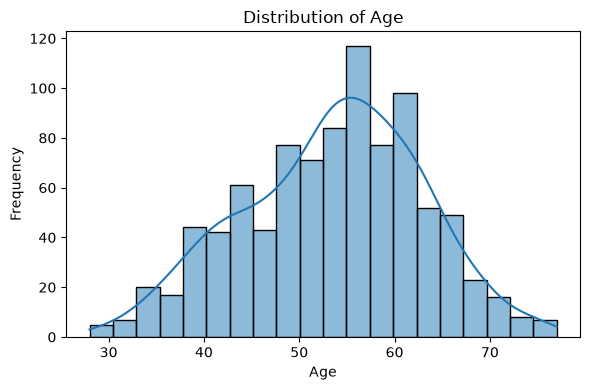

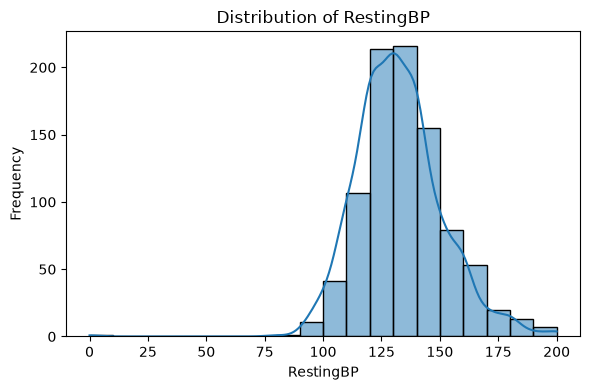

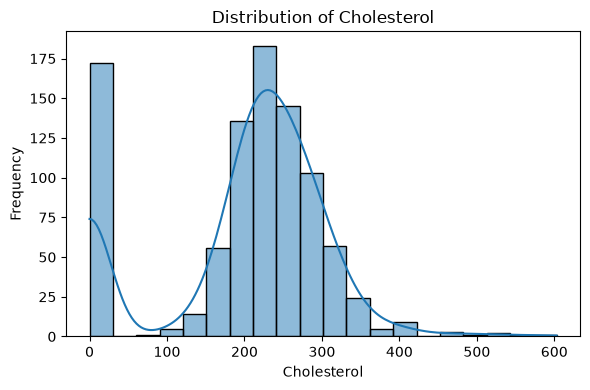

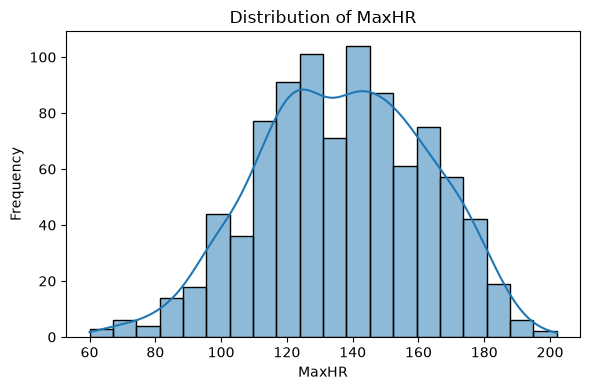

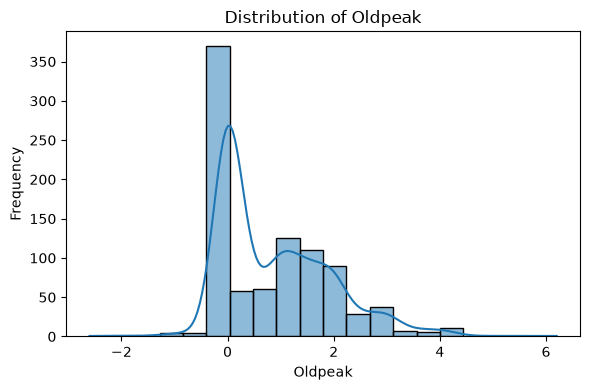

In [13]:
numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

for col in numerical_features:
    plt.figure(figsize=(6, 4))

    sns.histplot(df[col], bins=20, kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### Interpretation

The histograms show the distributions and overall patterns of the numerical features.

* **Age:** The distribution is centered around the 50s, with most patients falling approximately between 40 and 65 years. The distribution is relatively symmetric with fewer observations at the younger and older age ranges.

* **RestingBP:** Most observations are concentrated between approximately 110 and 160 mmHg. There are relatively few observations at the extreme values, including a single zero value that will be investigated as an invalid measurement.

* **Cholesterol:** Most non-zero observations are concentrated approximately between 150 and 300 mg/dL. The distribution contains a large number of zero values, which are not realistic cholesterol measurements and will therefore be treated as invalid/missing values.

* **MaxHR:** The distribution is centered around approximately 130–150, with most observations falling roughly between 100 and 180. A smaller number of observations appear at the lower and higher ends of the distribution.

* **Oldpeak:** The distribution is strongly right-skewed. Most observations are concentrated around lower values, particularly between 0 and 2, while fewer observations extend toward higher values. Some extreme values will be examined further using boxplots.

Overall, the numerical features have different distributions and ranges. The histograms help identify the general patterns and highlight values that require further investigation during the data cleaning and outlier analysis stages.


## Step 8 — Detecting Potential Outliers

Boxplots are used to identify potential statistical outliers in the numerical features.

However, an observation being a statistical outlier does not necessarily mean that it is an invalid value. Since this is a medical dataset, extreme measurements may represent genuine patient conditions.


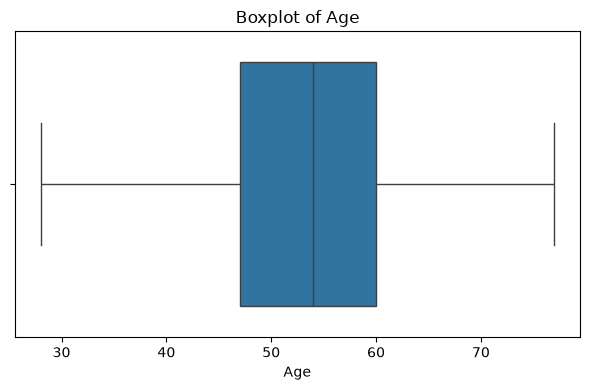

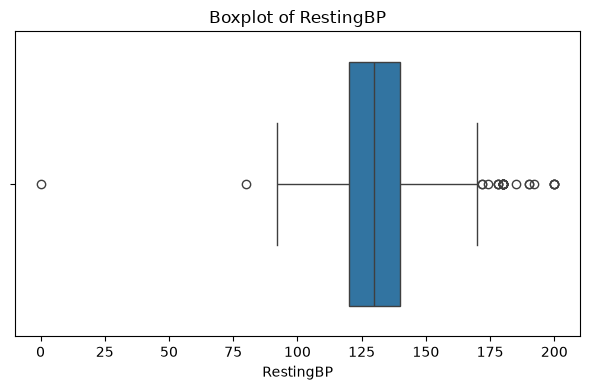

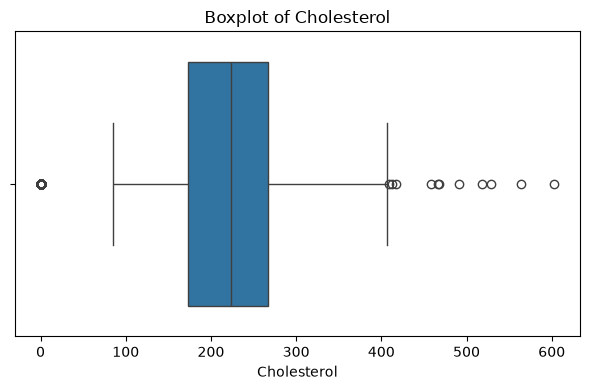

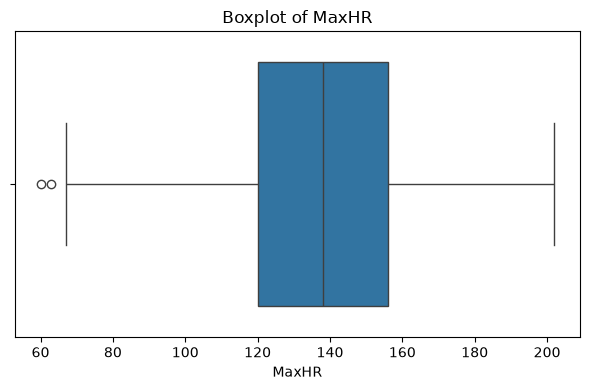

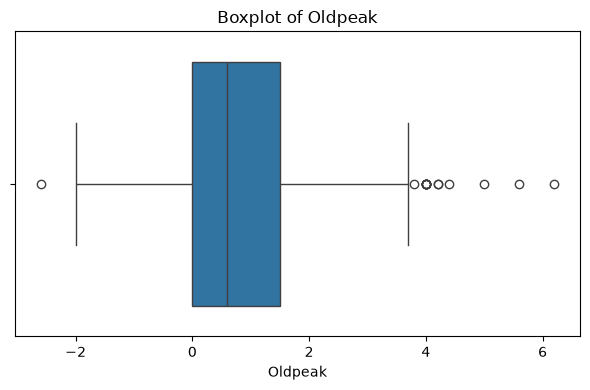

In [ ]:
for col in numerical_features:
    plt.figure(figsize=(6, 4))

    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

### Interpretation

The boxplots were used to identify potential outliers and unusual values in the numerical features.

* **Age:** The values are distributed mainly between approximately 30 and 75 years, with no clear outliers. The distribution appears reasonable without extreme observations.

* **RestingBP:** Most values are concentrated around 110–160 mmHg. A clear outlier at **0** is present, which is not a physiologically valid blood pressure measurement and should therefore be investigated as an invalid value. Some higher values also appear as outliers, but these may represent patients with unusually high blood pressure and should not be removed automatically.

* **Cholesterol:** Most non-zero values are concentrated approximately between 150 and 300 mg/dL. A **zero value** is present, which is not a realistic cholesterol measurement and should be treated as an invalid/missing value. Several high cholesterol values, extending to approximately 400–600 mg/dL, are also identified as outliers. Although these values are extreme, they may represent genuine medical measurements and should not be removed solely because they are statistical outliers.

* **MaxHR:** Most observations are concentrated approximately between 100 and 180. A few unusually low values are identified as outliers. These values may reflect individual patient characteristics or medical conditions, so they should be investigated rather than automatically removed.

* **Oldpeak:** Most observations are concentrated at lower values, mainly between 0 and 2. Several higher values are identified as outliers, along with a low value. Since Oldpeak is a clinical measurement, extreme values may contain meaningful information about individual patients and should not be removed without further investigation.

Overall, the boxplots reveal several statistical outliers, particularly in `RestingBP`, `Cholesterol`, `MaxHR`, and `Oldpeak`. However, an outlier is not necessarily an error. Since this is a medical dataset, extreme values may represent real patient conditions. Therefore, **only clearly invalid values, such as zero values in `RestingBP` and `Cholesterol`, will be investigated and handled as invalid measurements, while medically plausible extreme values will be retained.**


## Step 9 — Handling Invalid Values in RestingBP

The minimum and maximum values of `RestingBP` are examined.

A value of `0` is not a realistic resting blood pressure measurement, so these values are considered invalid rather than genuine observations.


In [14]:
df["RestingBP"].min(), df["RestingBP"].max()

(np.int64(0), np.int64(200))

In [15]:
(df["RestingBP"] == 0).sum()

np.int64(1)

In [16]:
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)

### Decision

The single `RestingBP` value equal to `0` was replaced with `NaN`.

The missing value will be handled later during preprocessing using median imputation rather than removing the entire observation.


### Visualizing RestingBP

The boxplot is visualized again after handling the invalid value.

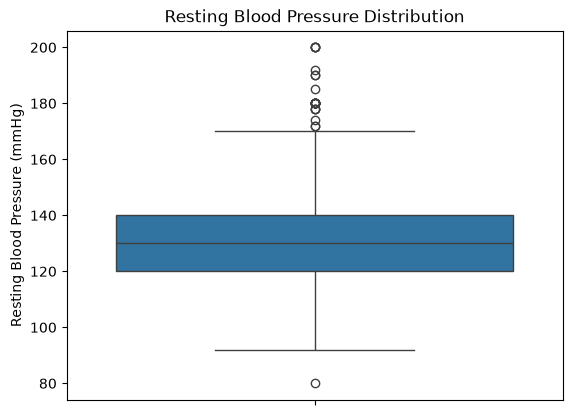

In [18]:
sns.boxplot(
    data=df,
    y="RestingBP"
)

plt.title("Resting Blood Pressure Distribution")
plt.ylabel("Resting Blood Pressure (mmHg)")
plt.show()

## Step 10 — Handling Outliers in Oldpeak

The `Oldpeak` feature contains values ranging from **-2.6 to 6.2**, with some extreme values visible in the boxplot.

Although these observations may appear as statistical outliers, they may represent genuine clinical measurements.

Therefore, they were retained rather than removed or clipped.


In [19]:
df["Oldpeak"].min(), df["Oldpeak"].max()

(np.float64(-2.6), np.float64(6.2))

In [54]:
df["Oldpeak"].describe()

count    918.000000
mean       0.887364
std        1.066570
min       -2.600000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64

## Step 11 — Handling Outliers in MaxHR

Some low `MaxHR` values appear as statistical outliers.

These observations were investigated to determine whether they could represent realistic patient measurements.

Since the values may reflect genuine physiological conditions, they were retained.


In [20]:
df["MaxHR"].min(), df["MaxHR"].max()

(np.int64(60), np.int64(202))

In [21]:
df[df["MaxHR"] < 80][["Age", "MaxHR", "HeartDisease"]]

,Age,MaxHR,HeartDisease
318,61,77,1
360,62,72,1
370,60,63,1
390,51,60,1
399,61,70,1
402,65,67,1
407,62,72,1
410,62,78,1
496,58,69,0
550,55,73,1



The `MaxHR` feature contained some low values that were identified as statistical outliers in the boxplot. However, these values were not considered invalid because they fall within a possible physiological range and may represent genuine measurements from patients with cardiovascular conditions.

Since these observations may contain important information related to heart disease, they were retained and were not removed or clipped.

Therefore, no outlier treatment was applied to `MaxHR`.


## Step 12 — Handling Invalid Values in Cholesterol

The `Cholesterol` feature contains several values equal to `0`.

A cholesterol level of `0 mg/dL` is not considered a realistic measurement. Therefore, these values are treated as invalid/missing values rather than genuine observations.


In [17]:
(df["Cholesterol"] == 0).sum()

np.int64(172)

In [18]:
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)

In [19]:
df["Cholesterol"].isna().sum()

np.int64(172)

### Decision

The **172 zero values** in `Cholesterol` were replaced with `NaN`.

The remaining high cholesterol values were retained because they may represent genuine medical conditions.

The missing values will be handled later during preprocessing using:

```python
SimpleImputer(strategy="median")
```


### Visualizing Cholesterol

The boxplot is visualized again after handling the invalid values.

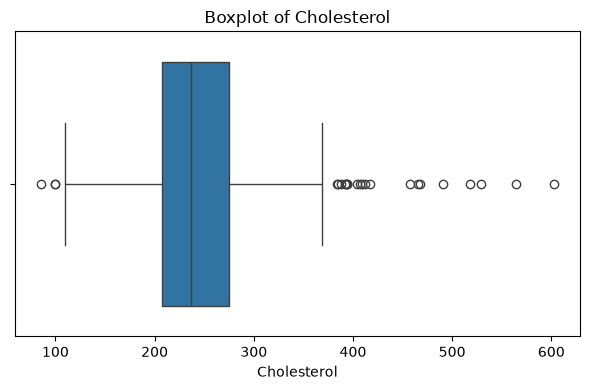

In [6]:
plt.figure(figsize=(6, 4))

sns.boxplot(x=df["Cholesterol"])

plt.title("Boxplot of Cholesterol")
plt.xlabel("Cholesterol")

plt.tight_layout()
plt.show()

## Step 13 — Checking Missing Values After Cleaning

The missing values are checked again after replacing the invalid zero values.

At this stage:

* `RestingBP` contains **1 missing value**.
* `Cholesterol` contains **172 missing values**.
* The remaining features contain no missing values.

These missing values will be handled during the preprocessing stage.


In [25]:
df.isnull().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

## Step 14 — Numerical Features vs Heart Disease

The numerical features are compared between patients with and without heart disease.

Boxplots and group means are used to identify differences between the two target classes.


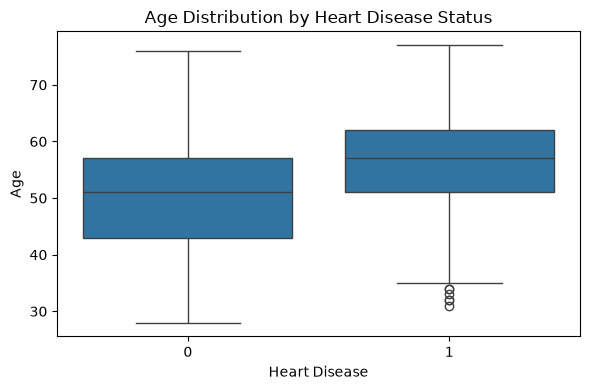

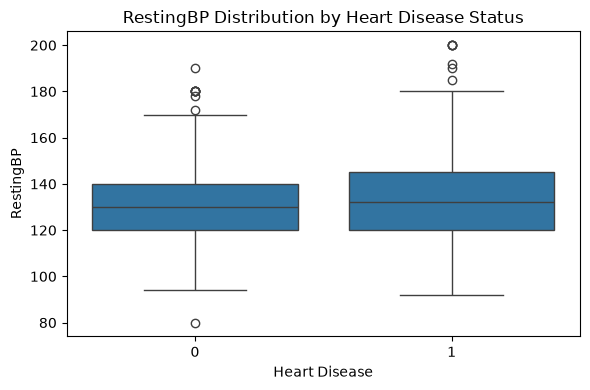

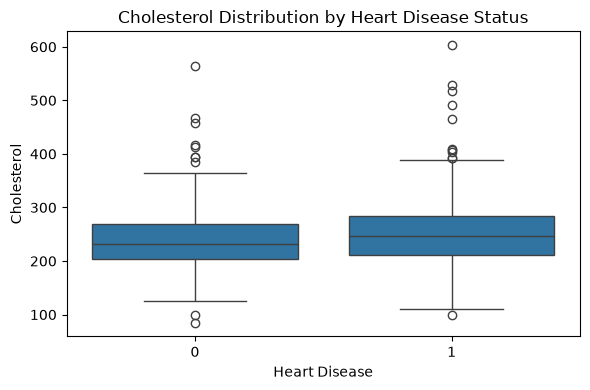

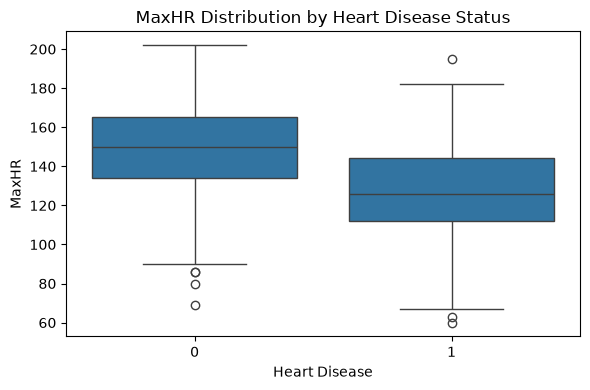

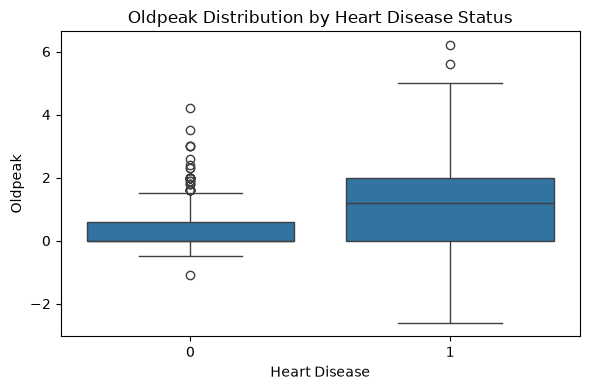

In [20]:
for col in numerical_features:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        data=df,
        x="HeartDisease",
        y=col
    )

    plt.title(f"{col} Distribution by Heart Disease Status")
    plt.xlabel("Heart Disease")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

### Interpretation

The boxplots compare the distributions of the numerical features between patients **without heart disease (`HeartDisease = 0`)** and patients **with heart disease (`HeartDisease = 1`)**.

* **Age:** Patients with heart disease tend to be slightly older. The median age for the heart disease group is higher than for the non-heart disease group. The heart disease group also shows a few lower-age outliers.

* **RestingBP:** The median RestingBP is relatively similar between the two groups, although the heart disease group shows a slightly higher median. Both groups contain some extreme values, including very low and high blood pressure measurements. These should not be removed automatically because they may represent genuine medical conditions.

* **Cholesterol:** The median cholesterol levels are relatively similar between the two groups. The non-heart disease group contains several high cholesterol outliers, while the heart disease group has a wider distribution and includes very low values, including zero values. Since a cholesterol value of zero is not physiologically realistic, these values should be investigated as invalid measurements.

* **MaxHR:** The heart disease group generally has a **lower median MaxHR** compared with the non-heart disease group. The non-heart disease group shows a wider range toward higher maximum heart rates, while both groups contain some lower extreme values.

* **Oldpeak:** The difference between the two groups is more noticeable for Oldpeak. Patients with heart disease tend to have a **higher median Oldpeak** and a wider distribution, while the non-heart disease group is more concentrated around lower values. Several high values appear as outliers in both groups.

Overall, the boxplots suggest that **Age, MaxHR, and Oldpeak show noticeable differences between patients with and without heart disease**, while RestingBP and Cholesterol have more similar central distributions. These differences may indicate that some numerical features contain useful information for predicting heart disease.

However, the presence of outliers does not necessarily indicate incorrect data. Since these are medical measurements, extreme values may represent real patient conditions. Therefore, they should be interpreted carefully rather than removed automatically.


In [21]:
df.groupby("HeartDisease")[numerical_features].mean()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
HeartDisease,,,,,
0,50.551220,130.180488,238.769231,148.151220,0.408049
1,55.899606,134.449704,251.061798,127.655512,1.274213


### Result Interpretation

After removing the invalid zero values, the group means provide a clearer comparison between patients with and without heart disease.

- **Age:** Patients with heart disease (**HeartDisease = 1**) have a higher average age (**55.90**) compared to patients without heart disease (**50.55**).

- **RestingBP:** The average resting blood pressure is higher in patients with heart disease (**134.45**) than in patients without heart disease (**130.18**).

- **Cholesterol:** Patients with heart disease have a higher average cholesterol level (**251.06**) compared to patients without heart disease (**238.77**). Removing the invalid zero values makes this comparison more representative.

- **MaxHR:** Patients without heart disease have a higher average maximum heart rate (**148.15**) compared to patients with heart disease (**127.66**).

- **Oldpeak:** The average Oldpeak is considerably higher in patients with heart disease (**1.27**) compared to patients without heart disease (**0.41**).

Overall, patients with heart disease tend to be older and have higher average **RestingBP, Cholesterol, and Oldpeak**, while patients without heart disease tend to have a higher average **MaxHR**. These differences suggest that these numerical features may provide useful information for distinguishing between the two heart disease classes.

## Step 15 — Categorical Feature Analysis

The categorical features are analyzed to understand their distributions and identify possible relationships with heart disease.

The categorical features include:

* `Sex`
* `ChestPainType`
* `RestingECG`
* `ExerciseAngina`
* `ST_Slope`


In [30]:
categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

In [21]:
for col in categorical_features:
    print(f"\n{col}")
    print(df[col].value_counts())


Sex
Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


### Interpretation

The categorical features have different distributions across their categories.

* **Sex:** The dataset contains **725 male** patients and **193 female** patients, showing that male patients make up the majority of the dataset.
* **ChestPainType:** `ASY` is the most common chest pain category with **496 observations**, followed by `NAP` with **203**, `ATA` with **173**, and `TA` with **46**.
* **RestingECG:** `Normal` is the most common category with **552 observations**, followed by `LVH` with **188** and `ST` with **178**.
* **ExerciseAngina:** Most patients have `N` with **547 observations**, while `Y` appears in **371 observations**.
* **ST_Slope:** `Flat` is the most common category with **460 observations**, followed by `Up` with **395**, while `Down` is less common with **63 observations**.

Overall, some categories are more frequent than others, particularly `M` in `Sex`, `ASY` in `ChestPainType`, `Normal` in `RestingECG`, `N` in `ExerciseAngina`, and `Flat` in `ST_Slope`.


### Visualizing Categorical Feature Distributions

Count plots are used to visualize the frequency of each category within the categorical features.

The distributions show that:

* `Sex` is dominated by male patients.
* `ChestPainType` is mainly represented by `ASY`, followed by `NAP` and `ATA`.
* `Normal` is the most common category in `RestingECG`.
* `N` is more common than `Y` in `ExerciseAngina`.
* `Flat` and `Up` are the most common categories in `ST_Slope`.

These visualizations provide an overview of the categorical feature distributions before analyzing their relationship with `HeartDisease`.


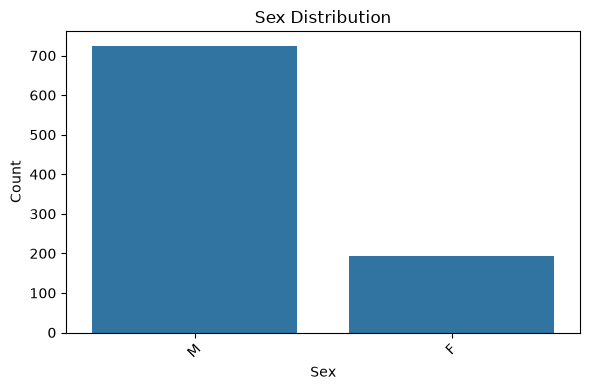

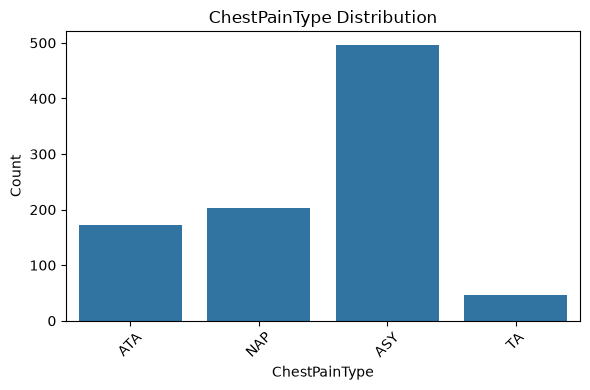

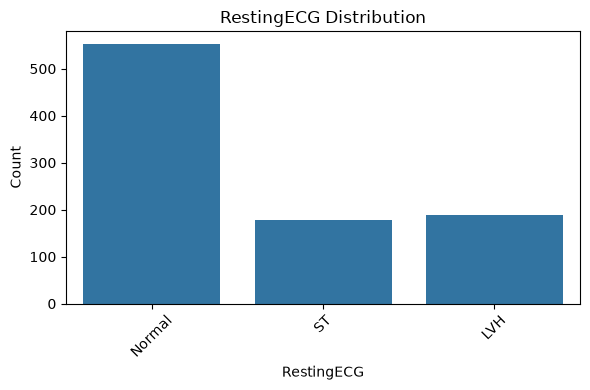

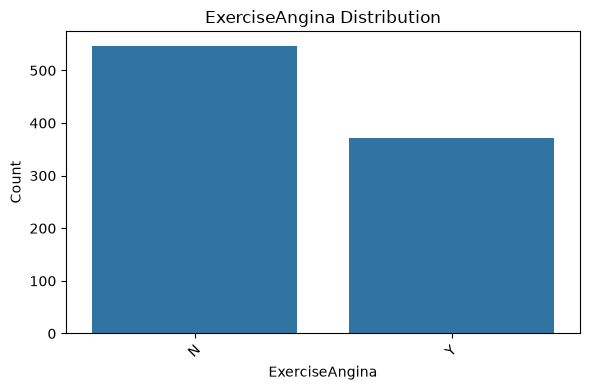

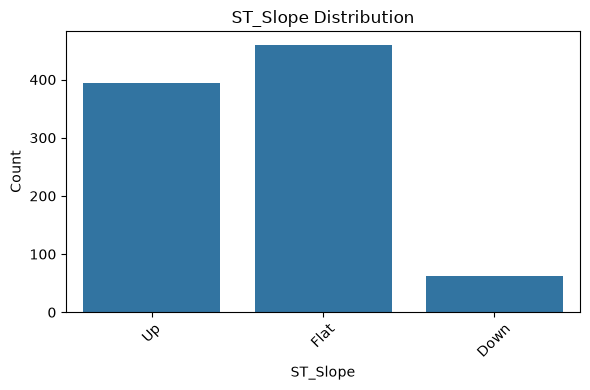

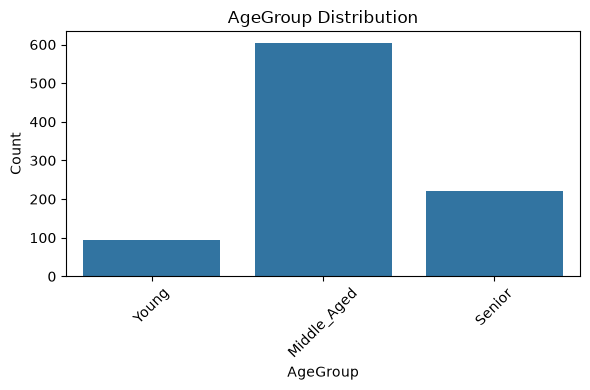

In [68]:
for col in categorical_features:
    plt.figure(figsize=(6, 4))

    sns.countplot(data=df, x=col)

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

### Visualization Interpretation

The count plots visually confirm the distributions observed in the frequency analysis.

The plots show that some categories are considerably more frequent than others. In particular, `Sex`, `ChestPainType`, and `ST_Slope` show noticeable differences in the number of observations across their categories.

These visualizations provide a clearer overview of the categorical feature distributions before investigating their relationships with `HeartDisease`.


## Step 16 — Chest Pain Type vs Heart Disease

The relationship between `ChestPainType` and `HeartDisease` is analyzed using a normalized cross-tabulation.

Using percentages within each chest pain category makes it easier to compare the proportion of heart disease across categories.


In [31]:
pd.crosstab(
    df["ChestPainType"],
    df["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
ChestPainType,,
ASY,20.967742,79.032258
ATA,86.127168,13.872832
NAP,64.532020,35.467980
TA,56.521739,43.478261


### Interpretation

`ChestPainType` shows a strong relationship with heart disease.

The `ASY` category has the highest proportion of heart disease at approximately **79%**, while `ATA` has the lowest proportion at approximately **14%**.

This suggests that `ChestPainType` may be an important predictive feature.


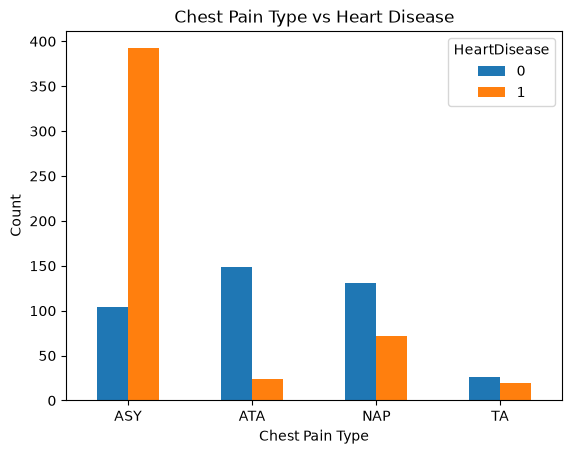

In [32]:
pd.crosstab(
    df["ChestPainType"],
    df["HeartDisease"]
).plot(kind="bar")

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The bar plot provides a visual representation of the relationship between `ChestPainType` and `HeartDisease` observed in the cross-tabulation above.


## Step 17 — Sex vs Heart Disease

The relationship between `Sex` and `HeartDisease` is examined using a normalized cross-tabulation.


In [33]:
pd.crosstab(
    df["Sex"],
    df["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
Sex,,
F,74.093264,25.906736
M,36.827586,63.172414


### Interpretation

Approximately **63.2% of males** in the dataset have heart disease, compared with approximately **25.9% of females**.

This indicates a noticeable difference between the two groups and suggests that `Sex` may provide useful predictive information.


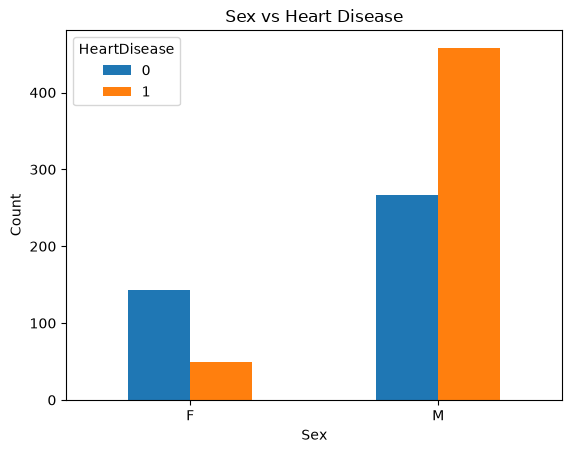

In [34]:
pd.crosstab(
    df["Sex"],
    df["HeartDisease"]
).plot(kind="bar")

plt.title("Sex vs Heart Disease")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The bar plot provides a visual representation of the differences in heart disease rates between male and female patients observed in the cross-tabulation above.


## Step 18 — ST Slope vs Heart Disease

The relationship between `ST_Slope` and `HeartDisease` is analyzed to determine whether the different ST slope categories are associated with different heart disease rates.


In [5]:
pd.crosstab(
    df["ST_Slope"],
    df["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
ST_Slope,,
Down,22.222222,77.777778
Flat,17.173913,82.826087
Up,80.253165,19.746835


### Interpretation

`ST_Slope` shows a strong relationship with heart disease.

Approximately **82.8%** of patients with a `Flat` ST slope and **77.8%** of patients with a `Down` slope have heart disease, compared with approximately **19.7%** for the `Up` category.

Therefore, `ST_Slope` appears to be an important predictive feature.


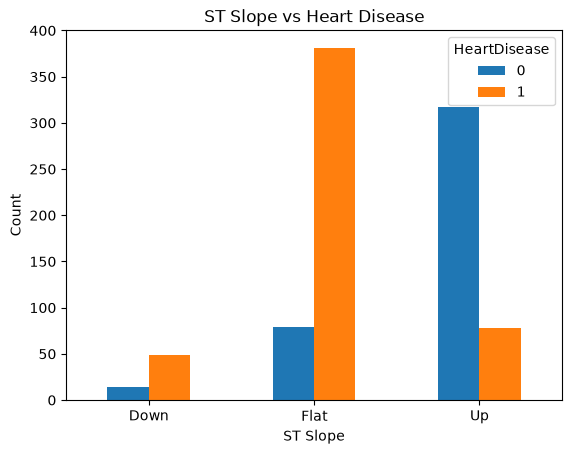

In [6]:
pd.crosstab(
    df["ST_Slope"],
    df["HeartDisease"]
).plot(kind="bar")

plt.title("ST Slope vs Heart Disease")
plt.xlabel("ST Slope")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The bar plot provides a visual representation of the differences in heart disease rates across the `ST_Slope` categories observed in the cross-tabulation above.


## Step 19 — Exercise Angina vs Heart Disease

The relationship between `ExerciseAngina` and `HeartDisease` is examined using a normalized cross-tabulation.


In [7]:
pd.crosstab(
    df["ExerciseAngina"],
    df["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
ExerciseAngina,,
N,64.899452,35.100548
Y,14.824798,85.175202


### Interpretation

Approximately **85.2%** of patients with exercise-induced angina (`Y`) have heart disease, compared with approximately **35.1%** of patients without exercise angina (`N`).

This represents a strong relationship and suggests that `ExerciseAngina` may be an important predictive feature.


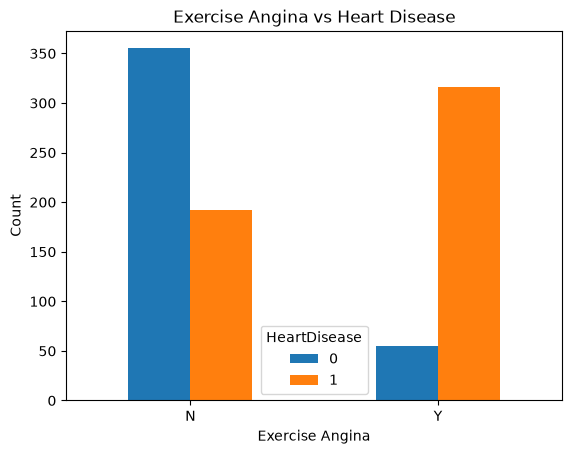

In [8]:
pd.crosstab(
    df["ExerciseAngina"],
    df["HeartDisease"]
).plot(kind="bar")

plt.title("Exercise Angina vs Heart Disease")
plt.xlabel("Exercise Angina")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The bar plot provides a visual representation of the relationship between `ExerciseAngina` and `HeartDisease` observed in the cross-tabulation above.


## Step 20 — Resting ECG vs Heart Disease

The relationship between `RestingECG` and `HeartDisease` is analyzed to compare the proportion of heart disease across the different ECG categories.


In [9]:
pd.crosstab(
    df["RestingECG"],
    df["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
RestingECG,,
LVH,43.617021,56.382979
Normal,48.369565,51.630435
ST,34.269663,65.730337


### Interpretation

The `ST` category has the highest proportion of heart disease at approximately **65.7%**, followed by `LVH` at approximately **56.4%** and `Normal` at approximately **51.6%**.

The differences are smaller than those observed for features such as `ST_Slope` and `ExerciseAngina`.


## Step 21 — Fasting Blood Sugar vs Heart Disease

The relationship between `FastingBS` and `HeartDisease` is examined to determine whether elevated fasting blood sugar is associated with a higher proportion of heart disease.


In [26]:
pd.crosstab(
    df["FastingBS"],
    df["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
FastingBS,,
0,51.988636,48.011364
1,20.560748,79.439252


### Interpretation

Approximately **79.4%** of patients with `FastingBS = 1` have heart disease, compared with approximately **48.0%** for `FastingBS = 0`.

This indicates a noticeable relationship between fasting blood sugar and heart disease in this dataset.


## Step 22 — Correlation Analysis

A correlation matrix is calculated for the numerical features and the target variable.

The correlation matrix helps identify the strength and direction of linear relationships between numerical variables.



In [22]:
corr = df.corr(numeric_only=True)

corr

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.263084,0.058758,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.263084,1.000000,0.095939,0.067823,-0.109693,0.174252,0.117990
Cholesterol,0.058758,0.095939,1.000000,0.054012,-0.019856,0.058488,0.103866
FastingBS,0.198039,0.067823,0.054012,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.109693,-0.019856,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.174252,0.058488,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.117990,0.103866,0.267291,-0.400421,0.403951,1.000000


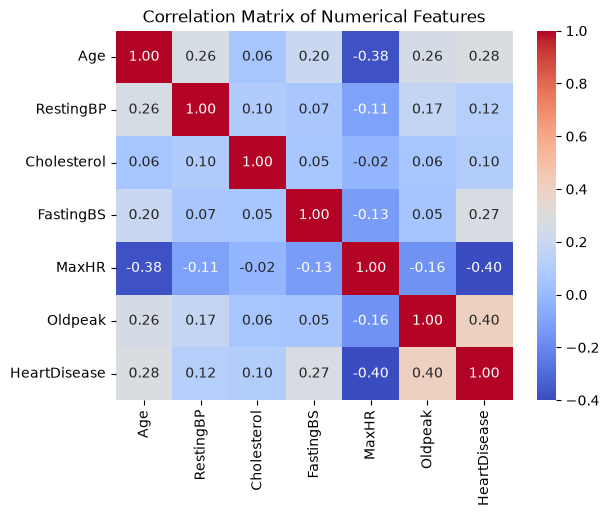

In [23]:
plt.Figure(figsize=(14,10))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")

plt.show()

### Interpretation

The strongest correlations with `HeartDisease` are:

* `Oldpeak`: **0.40** — moderate positive relationship.
* `MaxHR`: **-0.40** — moderate negative relationship.
* `Age`: **0.28** — weak positive relationship.
* `FastingBS`: **0.27** — weak positive relationship.
* `RestingBP`: **0.12** — very weak positive relationship.
* `Cholesterol`: **0.10** — very weak positive relationship.

After removing the invalid zero values from `Cholesterol`, its correlation with `HeartDisease` changed from a weak negative relationship to a very weak positive relationship. This indicates that the previous negative correlation was likely influenced by the invalid zero values.

The results suggest that `Oldpeak` and `MaxHR` have the strongest linear relationships with `HeartDisease`, followed by `Age` and `FastingBS`. `RestingBP` and `Cholesterol` show only very weak positive relationships with the target.

However, correlation only measures linear relationships. Therefore, a low correlation does not necessarily mean that a feature is not useful for a machine learning model.

## EDA Summary

The EDA provided several important insights into the dataset.

- The target variable is relatively balanced, with a slightly higher proportion of patients with heart disease.
- No duplicate records were found.
- Invalid zero values were identified in `RestingBP` and `Cholesterol` and were converted to missing values for later imputation.
- Potential outliers in the numerical features were investigated and retained when they could represent valid clinical measurements.
- `Age`, `Oldpeak`, and `MaxHR` showed noticeable differences between patients with and without heart disease.
- `ChestPainType`, `ST_Slope`, `ExerciseAngina`, and `FastingBS` showed noticeable associations with `HeartDisease`.
- The correlation analysis showed that `Oldpeak` and `MaxHR` had the strongest linear relationships with the target among the numerical features.

Overall, the EDA provided a better understanding of the data quality, feature distributions, and relationships with heart disease. These findings will guide the preprocessing and feature handling steps before building the machine learning models.

# Supervised Learning

After completing the Exploratory Data Analysis (EDA), the next step is to build and evaluate supervised machine learning models to predict heart disease.

In this section, the dataset will be prepared for modeling, a baseline classification model will be trained, and different models will be compared using appropriate evaluation metrics.

## Step 1 — Feature Engineering

Based on the EDA findings, `Age` showed a positive relationship with `HeartDisease`, indicating that age may be an important factor in the classification task.

To provide the model with another representation of age, the continuous `Age` feature is transformed into three meaningful age groups:

- `Young`: below 40
- `Middle-aged`: 40–60
- `Senior`: above 60

The `AgeGroup` feature allows the model to capture possible differences between age ranges rather than relying only on the exact numerical age.

The original `Age` feature is kept because converting it into categories may lose some numerical information.

In addition, a `health_risk_count` feature is created to summarize several health-related risk factors into a single numerical feature.

The `health_risk_count` represents the number of the following risk factors present for each patient:

- `RestingBP >= 140`: elevated resting blood pressure
- `Cholesterol >= 240`: high cholesterol
- `FastingBS == 1`: elevated fasting blood sugar

Each risk factor contributes one point to the count.

This feature provides the model with a simple summary of the patient's overall risk-factor profile while keeping the original features available.

In [24]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 40, 60, 100],
    labels=["Young", "Middle_Aged", "Senior"]
)

In [25]:
df["health_risk_count"] = (
    (df["RestingBP"] >= 140).astype(int)
    + (df["Cholesterol"] >= 240).astype(int)
    + (df["FastingBS"] == 1).astype(int)
)

In [26]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,health_risk_count
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0,Young,2
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1,Middle_Aged,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0,Young,1
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1,Middle_Aged,0
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0,Middle_Aged,1


## Step 2 — Separate Features and Target

The target variable `HeartDisease` is separated from the input features.

`HeartDisease` is the binary classification target:

- `0` — No heart disease
- `1` — Heart disease

All remaining columns are used as input features.

In [27]:
X = df.drop(columns="HeartDisease")
y = df["HeartDisease"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'AgeGroup', 'health_risk_count'],
      dtype='str')

Target:
HeartDisease


## Step 3 — Train/Test Split

The dataset is divided into training and test sets.

The training set is used to train the models and perform cross-validation.

The test set is kept separate and is used only for the final evaluation.

Stratification is used to maintain a similar distribution of the target classes in both sets.

In [28]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (734, 13)
Test set: (184, 13)


## Step 4 — Identify Numerical and Categorical Features

The input features are divided into numerical and categorical variables.

Numerical features will be imputed and standardized, while categorical features will be imputed and encoded.

The engineered `AgeGroup` feature is included as a categorical feature because it represents age ranges.

The engineered `health_risk_count` feature is included as a numerical feature because it represents the total number of identified health risk factors.

In [60]:
numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "health_risk_count"
]

categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
    "AgeGroup"
]

## Step 5 — Build the Preprocessing Pipeline

A `ColumnTransformer` is used to apply different preprocessing steps to numerical and categorical features.

For numerical features:

- Missing values are replaced using the median.
- Features are standardized using `StandardScaler`.

For categorical features:

- Missing values are replaced using the most frequent category.
- Categories are converted into numerical values using `OneHotEncoder`.

The preprocessing is included inside the pipeline to ensure that transformations are learned only from the training data and to help prevent data leakage during cross-validation.

In [61]:

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

## Step 6 — Logistic Regression Baseline

Logistic Regression is used as the baseline classification model.

It is a simple and commonly used model for binary classification. It provides a reference point that can later be compared with a more flexible model such as Random Forest.

The preprocessing steps are combined with Logistic Regression in a single Pipeline to ensure that the same preprocessing is applied consistently during training and validation.

In [31]:

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

## Step 7 — 5-Fold Stratified Cross-Validation

Five-fold stratified cross-validation is used to evaluate the Logistic Regression baseline.

The training data is divided into five folds. In each iteration, four folds are used for training and one fold is used for validation.

Stratification maintains a similar proportion of `HeartDisease` classes across the folds.

The same cross-validation strategy will later be used for the Random Forest model to ensure a fair comparison.

In [32]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Step 8 — Evaluate the Baseline

In [33]:

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

### Display Results

In [34]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": logistic_cv["test_accuracy"].mean(),
    "Precision": logistic_cv["test_precision"].mean(),
    "Recall": logistic_cv["test_recall"].mean(),
    "F1": logistic_cv["test_f1"].mean(),
    "ROC-AUC": logistic_cv["test_roc_auc"].mean()
}

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': np.float64(0.8474326716988166),
 'Precision': np.float64(0.8579238351721834),
 'Recall': np.float64(0.8719963866305329),
 'F1': np.float64(0.8640176827325415),
 'ROC-AUC': np.float64(0.9222187127336179)}

## Step 9  — Random Forest Comparison Model

Random Forest is selected as the second classification model.

Unlike Logistic Regression, Random Forest can capture non-linear relationships and interactions between features.

This allows us to compare a simple linear classification model with a more flexible tree-based model.

In [35]:

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    )
])

## Step 10 — Random Forest Cross-Validation

The Random Forest model is evaluated using the same five-fold stratified cross-validation strategy and the same evaluation metrics used for Logistic Regression.

Using the same methodology makes the comparison between the two models more consistent and reliable.

In [36]:
random_forest_cv = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

### Display Results

In [37]:
random_forest_results = {
    "Model": "Random Forest",
    "Accuracy": random_forest_cv["test_accuracy"].mean(),
    "Precision": random_forest_cv["test_precision"].mean(),
    "Recall": random_forest_cv["test_recall"].mean(),
    "F1": random_forest_cv["test_f1"].mean(),
    "ROC-AUC": random_forest_cv["test_roc_auc"].mean()
}

random_forest_results

{'Model': 'Random Forest',
 'Accuracy': np.float64(0.8542447115832633),
 'Precision': np.float64(0.8517524614314429),
 'Recall': np.float64(0.8965974104185486),
 'F1': np.float64(0.8725101823522644),
 'ROC-AUC': np.float64(0.9232654808806571)}

## Step 11 — Model Comparison

The Logistic Regression baseline and Random Forest model are compared using the mean results from five-fold stratified cross-validation.

Both models were evaluated using the same training data, preprocessing steps, cross-validation strategy, and performance metrics.

The comparison helps determine which model provides stronger performance for predicting `HeartDisease`.

In [38]:
results = pd.DataFrame([
    logistic_results,
    random_forest_results
])

results.set_index("Model")

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.847433,0.857924,0.871996,0.864018,0.922219
Random Forest,0.854245,0.851752,0.896597,0.872510,0.923265


### Result Interpretation

The comparison shows that **Random Forest is the better model overall**.  
It provides a better balance between identifying positive cases and avoiding incorrect predictions, as reflected by its slightly higher **Recall, F1-Score, and ROC-AUC**. This indicates that Random Forest generalizes slightly better and is more effective at distinguishing between the two classes.

## Step 12 — Visualize Model Comparison

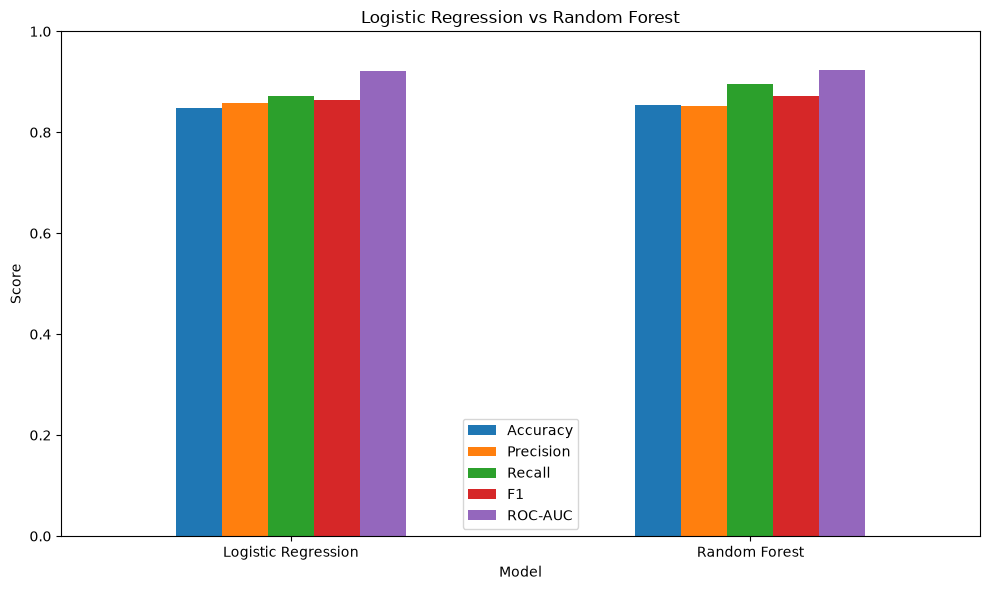

In [39]:
results_plot = results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Logistic Regression vs Random Forest")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Model Performance Visualization

The bar chart below visualizes the same evaluation results presented in the table above, allowing for an easier comparison between Logistic Regression and Random Forest across all performance metrics.

## Step 13 -Evaluate the Impact of Engineered Features

After creating the `AgeGroup` and `health_risk_count` features, their impact on the Random Forest model is evaluated separately.

The goal is to determine whether the engineered features provide useful additional information or negatively affect model performance.

Four feature sets are compared:

- **Original Features:** The original features without any engineered features.
- **Original + `AgeGroup`:** Adds the age-group representation to the original features.
- **Original + `health_risk_count`:** Adds the combined health-risk feature to the original features.
- **Original + Both:** Includes both engineered features.

The same Random Forest configuration, preprocessing steps, five-fold cross-validation strategy, and F1 scoring metric are used for all four experiments. This ensures that the comparison focuses only on the effect of the engineered features.

The comparison is performed using the training data only. The test set remains unseen and will be used later for the final evaluation.

The feature set that achieves the best cross-validated F1 score will be selected for the next stage of the project.

In [40]:
base_numerical = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak"
]

base_categorical = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

In [41]:
def evaluate_random_forest(
    X_data,
    numerical_features,
    categorical_features
):
    
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]),
                numerical_features
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore"))
                ]),
                categorical_features
            )
        ]
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ])

    scores = cross_validate(
        pipeline,
        X_data,
        y_train,
        cv=cv,
        scoring="f1"
    )

    return scores["test_score"].mean()

In [42]:
X_original = X_train[
    base_numerical + base_categorical
]

original_f1 = evaluate_random_forest(
    X_original,
    base_numerical,
    base_categorical
)

print("Original Features F1:", original_f1)

Original Features F1: 0.8666421386260126


In [43]:
X_age = X_train[
    base_numerical + base_categorical + ["AgeGroup"]
]

age_f1 = evaluate_random_forest(
    X_age,
    base_numerical,
    base_categorical + ["AgeGroup"]
)

print("Original + AgeGroup F1:", age_f1)

Original + AgeGroup F1: 0.8712656807884764


In [44]:
X_risk = X_train[
    base_numerical + base_categorical + ["health_risk_count"]
]

risk_f1 = evaluate_random_forest(
    X_risk,
    base_numerical + ["health_risk_count"],
    base_categorical
)

print("Original + health_risk_count F1:", risk_f1)

Original + health_risk_count F1: 0.8710152624774837


In [45]:
X_both = X_train[
    base_numerical
    + base_categorical
    + ["AgeGroup", "health_risk_count"]
]

both_f1 = evaluate_random_forest(
    X_both,
    base_numerical + ["health_risk_count"],
    base_categorical + ["AgeGroup"]
)

print("Original + AgeGroup + health_risk_count F1:", both_f1)

Original + AgeGroup + health_risk_count F1: 0.8725101823522644


In [46]:
feature_comparison = pd.DataFrame({
    "Feature Set": [
        "Original Features",
        "Original + AgeGroup",
        "Original + health_risk_count",
        "Original + Both"
    ],
    "CV F1": [
        original_f1,
        age_f1,
        risk_f1,
        both_f1
    ]
})

feature_comparison.sort_values(
    "CV F1",
    ascending=False
)

,Feature Set,CV F1
3,Original + Both,0.872510
1,Original + AgeGroup,0.871266
2,Original + health_risk_count,0.871015
0,Original Features,0.866642


### Feature Engineering Comparison

The engineered features were evaluated using five-fold cross-validation with F1 score to determine whether they improved the Random Forest model.

The results showed that **Original + Both** achieved the highest cross-validated F1 score of **0.8725**, compared with **0.8666** for the original features.

Adding `AgeGroup` resulted in a CV F1 score of **0.8713**, while adding `health_risk_count` resulted in **0.8710**. Although each engineered feature individually provided a small improvement, combining both features achieved the best overall performance.

Therefore, both `health_risk_count` and `AgeGroup` were retained in the final feature set because their combination provided the highest cross-validated F1 score.

## Step 14 — Hyperparameter Tuning with GridSearchCV


To further improve the Random Forest model, `GridSearchCV` is used to search for the best combination of Random Forest hyperparameters.

The tuning process is performed only on the training data. The test set remains completely unseen and will be used only for the final evaluation.

The hyperparameters selected for tuning are:

- `n_estimators`: Number of trees in the forest.
- `max_depth`: Maximum depth of each decision tree.
- `min_samples_split`: Minimum number of samples required to split an internal node.

Five-fold stratified cross-validation is used during the search to ensure a consistent evaluation process.

In [47]:

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

In [48]:
grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if

## Step 15 — Best Hyperparameters

After completing the grid search, the best combination of hyperparameters and its corresponding cross-validation F1-score are extracted.

These parameters represent the configuration that achieved the highest mean F1-score across the five validation folds.

In [49]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best Cross-Validation F1 Score:
0.8787167030419963


### Interpretation

The best Random Forest configuration found by GridSearchCV was:

- `n_estimators = 100`
- `max_depth = 10`
- `min_samples_split = 5`

This configuration achieved a mean cross-validation F1-score of approximately **0.879** across five stratified folds.

The result indicates that the tuned Random Forest performs well during cross-validation after optimizing the hyperparameters using the final feature set.

Both engineered features, `health_risk_count` and `AgeGroup`, were included in the final feature set used for tuning the Random Forest model.

The best estimator identified by GridSearchCV will now be used for the final evaluation on the held-out test set, which remained completely unseen during model selection and hyperparameter tuning.

## Step 16 — Select the Best Tuned Model

The best estimator identified by GridSearchCV is selected as the final Random Forest model.

The selected estimator contains both the preprocessing steps and the optimized Random Forest hyperparameters.

Before evaluating the model on the test set, the selected pipeline is inspected to verify that it uses the intended final feature set, including both `health_risk_count` and `AgeGroup`, and that the preprocessing and model configuration are correctly applied.

In [50]:
best_model = grid_search.best_estimator_

print("Selected Model:")
print(best_model)

Selected Model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'FastingBS',
                                                   'MaxHR', 'Oldpeak',
                                                   'health_risk_count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
          

"

## Step 17 — Final Evaluation on the Test Set

After completing feature selection, cross-validation, and hyperparameter tuning, the best Random Forest pipeline is evaluated on the held-out test set.

The test set has not been used during model training, feature selection, cross-validation, or hyperparameter tuning.

Therefore, this evaluation provides an unbiased estimate of how the final model performs on unseen data.

The predictions generated on the test set will be used to calculate Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [51]:
y_test_pred = best_model.predict(X_test)

y_test_prob = best_model.predict_proba(X_test)[:, 1]

## Step 18 — Final Test Performance

The final Random Forest model is evaluated using multiple classification metrics.

- **Accuracy** measures the overall proportion of correct predictions.
- **Precision** measures how many predicted heart disease cases were actually positive.
- **Recall** measures how many actual heart disease cases were correctly detected.
- **F1-score** provides a balance between precision and recall.
- **ROC-AUC** measures the model's ability to distinguish between patients with and without heart disease across different classification thresholds.

Since this is a heart disease prediction task, Recall is particularly important because failing to detect a patient with heart disease represents a false negative.

In [52]:

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Final Test Results")
print("------------------")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")

Final Test Results
------------------
Accuracy : 0.8859
Precision: 0.8857
Recall   : 0.9118
F1 Score : 0.8986
ROC-AUC  : 0.9332


### Interpretation

The final Random Forest model achieved strong performance on the unseen test set.

The model achieved:

- **Accuracy = 0.8859**
- **Precision = 0.8857**
- **Recall = 0.9118**
- **F1-score = 0.8986**
- **ROC-AUC = 0.9332**

The most important result is the **Recall of 0.9118**, meaning that the model correctly identified approximately **91% of the patients who actually had heart disease**.

The model also achieved an **F1-score of 0.8986**, indicating a strong balance between precision and recall.

The **ROC-AUC of 0.9332** indicates that the model has a strong ability to distinguish between patients with and without heart disease.

Overall, the final tuned Random Forest model demonstrates strong performance on unseen data and provides an improvement compared with the initial model comparison results.

## Step 19 — Confusion Matrix

A confusion matrix is used to examine the types of predictions made by the final Random Forest model.

It shows:

- **True Negative (TN):** Patients without heart disease correctly classified as negative.
- **False Positive (FP):** Patients without heart disease incorrectly classified as having heart disease.
- **False Negative (FN):** Patients with heart disease incorrectly classified as not having heart disease.
- **True Positive (TP):** Patients with heart disease correctly classified as positive.

For this problem, False Negatives are particularly important because they represent patients with heart disease who were not detected by the model.

In [54]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_test_pred)

print(cm)

[[70 12]
 [ 9 93]]


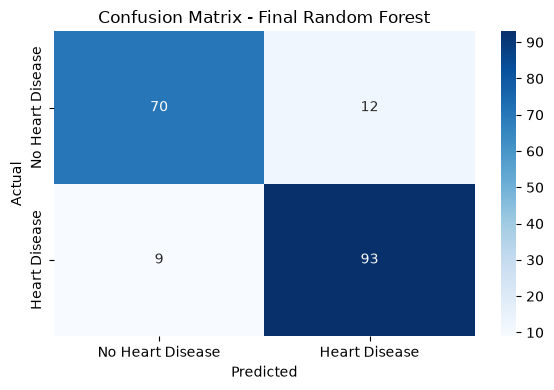

In [55]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.title("Confusion Matrix - Final Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### Interpretation

The confusion matrix shows that the final Random Forest model correctly classified most of the test observations.

The model produced:

- **True Negatives (TN) = 70**
- **False Positives (FP) = 12**
- **False Negatives (FN) = 9**
- **True Positives (TP) = 93**

The model correctly detected **93 out of 102 patients with heart disease**, resulting in a Recall of approximately **91.18%**.

Only **9 patients with heart disease were incorrectly classified as not having heart disease**. These False Negatives are particularly important because they represent cases that were missed by the model.

The model also produced **12 False Positives**, meaning some patients without heart disease were incorrectly classified as positive.

Overall, the confusion matrix indicates that the model performs well at detecting positive heart disease cases, which is consistent with its high Recall score.

## Step 20 — Classification Report

The classification report provides a detailed evaluation of the final Random Forest model for each target class.

It reports Precision, Recall, and F1-score for both patients without heart disease (`0`) and patients with heart disease (`1`).

This provides a more detailed view of the model's performance than the overall metrics alone.

In [56]:

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["No Heart Disease", "Heart Disease"]
))

                  precision    recall  f1-score   support

No Heart Disease       0.89      0.85      0.87        82
   Heart Disease       0.89      0.91      0.90       102

        accuracy                           0.89       184
       macro avg       0.89      0.88      0.88       184
    weighted avg       0.89      0.89      0.89       184



### Interpretation

The classification report provides a detailed evaluation of the final Random Forest model for both classes.

For patients **without heart disease (`0`)**:

- Precision = **0.89**
- Recall = **0.85**
- F1-score = **0.87**

For patients **with heart disease (`1`)**:

- Precision = **0.89**
- Recall = **0.91**
- F1-score = **0.90**

The model achieved a **Recall of 0.91 for the Heart Disease class**, meaning that it successfully detected most patients who actually had heart disease.

The model's **F1-score of 0.90 for the Heart Disease class** indicates a strong balance between precision and recall.

The lower recall for the No Heart Disease class (**0.85**) is consistent with the presence of **12 False Positives** identified in the confusion matrix.

Overall, the classification report confirms that the final Random Forest model performs well at identifying patients with heart disease while maintaining balanced performance across both classes.

## Step 21 — Final Model Evaluation

The final Random Forest model was selected after comparing multiple models, evaluating engineered features, and tuning the Random Forest hyperparameters using five-fold stratified cross-validation.

The final model uses the original features together with both engineered features, `health_risk_count` and `AgeGroup`.

GridSearchCV identified the following optimal Random Forest configuration:

- `n_estimators = 100`
- `max_depth = 10`
- `min_samples_split = 5`

The tuned model achieved a cross-validation F1-score of **0.8787**.

When evaluated on the completely unseen test set, the final model achieved:

- **Accuracy = 0.8859**
- **Precision = 0.8857**
- **Recall = 0.9118**
- **F1-score = 0.8986**
- **ROC-AUC = 0.9332**

The high Recall of **91.18%** for the Heart Disease class indicates that the model successfully identifies most patients with heart disease. Only **9 out of 102** actual heart disease cases were missed.

The final test F1-score of **0.8986** is higher than the cross-validation F1-score of **0.8787**. This difference does not by itself indicate overfitting, as the test set remained completely unseen during model training, feature selection, and hyperparameter tuning.

Overall, the final Random Forest model demonstrates strong performance in predicting heart disease and is particularly effective at detecting positive heart disease cases.

# Unsupervised Learning — K-Means Clustering

Unsupervised learning is used to explore hidden patterns and natural
groupings in the Heart Disease dataset without using the target variable.

In this section, K-Means clustering is applied to identify groups of
patients based on their numerical characteristics.

## Step 1 — Select Features for Clustering

K-Means clustering is applied to numerical patient characteristics to identify natural groupings within the dataset.

The target variable `HeartDisease` is intentionally excluded from the clustering process because K-Means is an unsupervised learning algorithm. Therefore, the clusters are formed based only on the selected patient features and not on the known heart disease labels.

The selected clustering features are:

- `Age`
- `RestingBP`
- `Cholesterol`
- `FastingBS`
- `MaxHR`
- `Oldpeak`
- `health_risk_count`

These features were selected because they represent demographic, cardiovascular, and health-risk characteristics that may help identify different patient profiles.

In [57]:
clustering_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "health_risk_count"
]

X_cluster = df[clustering_features]

## Step 2 — Handling Missing Values and Feature Scaling

Before applying K-Means, the clustering features are first checked for missing values and handled using median imputation. This step is necessary because K-Means does not accept missing values (`NaN`) directly.

In the supervised learning pipeline, missing values were already handled as part of the preprocessing pipeline. However, since the clustering process uses its own feature matrix, the missing values must be handled separately before applying K-Means.

After handling the missing values, the clustering features are standardized using `StandardScaler`.

Scaling is important because K-Means is based on distances between observations. The selected features have very different numerical ranges; for example, `Age` is measured in years, while `Cholesterol` can have values in the hundreds.

Without scaling, features with larger numerical ranges could have a greater influence on the distance calculations and therefore dominate the clustering process.

The scaler transforms the features to a common scale with approximately zero mean and unit variance, ensuring that all selected features contribute more fairly to the clustering process.

In [63]:
imputer = SimpleImputer(strategy="median")

X_cluster_imputed = imputer.fit_transform(X_cluster)

scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(X_cluster_imputed)

## Step 3 — Testing Different Numbers of Clusters

The optimal number of clusters is not known in advance.

Therefore, K-Means is evaluated using different values of `k`, ranging from 1 to 10. For each value of `k`, the model is fitted to the standardized data and the corresponding inertia is recorded.

Inertia represents the sum of squared distances between each observation and the centroid of its assigned cluster.

Lower inertia indicates that observations are closer to their cluster centroids. However, increasing the number of clusters will naturally reduce inertia, so the goal is to identify a point where adding more clusters provides relatively smaller improvements.

In [64]:

inertias = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)


## Step 4 — Determine the Number of Clusters

The Elbow Method is used to evaluate different numbers of clusters.

The inertia is calculated for values of `k` from 1 to 10. The resulting plot helps identify a suitable number of clusters by looking for an elbow point.

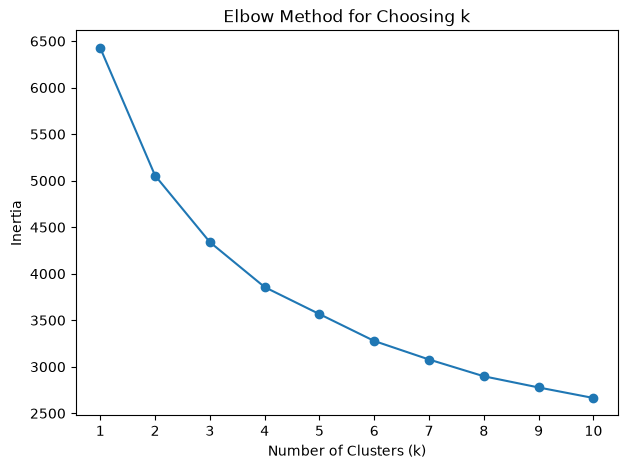

In [65]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, 11),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing k")
plt.xticks(range(1, 11))
plt.show()

## Step 5 — Evaluate Cluster Quality

The Silhouette Score is calculated for different values of `k` to evaluate how well the observations are separated into clusters.

A higher Silhouette Score indicates better-defined clusters.

In [66]:

for k in [2, 3, 4, 5]:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = km.fit_predict(X_cluster_scaled)
    
    score = silhouette_score(
        X_cluster_scaled,
        labels
    )
    
    print(f"k={k}: Silhouette Score = {score:.4f}")

k=2: Silhouette Score = 0.2103
k=3: Silhouette Score = 0.2045
k=4: Silhouette Score = 0.1944
k=5: Silhouette Score = 0.1849


Among the tested values, `k = 2` achieved the highest Silhouette Score of **0.2103**.

This supports the Elbow Method's indication that two clusters are a reasonable choice for this dataset.

The relatively low Silhouette Score also indicates that the clusters are not strongly separated. Therefore, the clustering should be interpreted as identifying broad patient groups rather than clearly distinct categories.

## Step 6 — Final K-Means Clustering

Based on the Elbow Method and Silhouette Score, two clusters were selected
for the final K-Means model.

The model was fitted using the scaled numerical features, and each patient
was assigned to one of the two clusters.

In [67]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_cluster_scaled)

df["Cluster"] = cluster_labels

In [68]:
df["Cluster"].value_counts().sort_index()

Cluster
0    401
1    517
Name: count, dtype: int64

### Cluster Distribution

The final K-Means model produced two clusters:

- **Cluster 0:** 401 patients
- **Cluster 1:** 517 patients

This indicates that the dataset was divided into two groups of different sizes based on similarities in the selected numerical health characteristics.

## Step 7 — Visualize the Clusters

The final clusters are visualized using a two-dimensional scatter plot based on `Age` and `MaxHR`.

This visualization provides a simple view of how the patients are distributed across the two clusters.

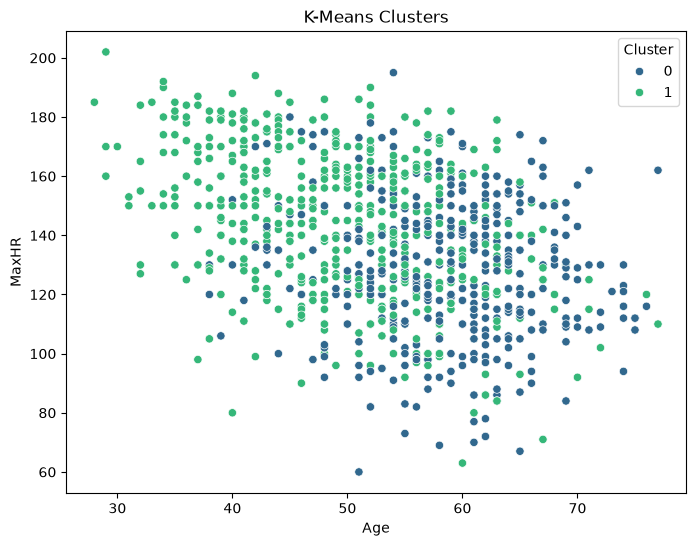

In [69]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="MaxHR",
    hue="Cluster",
    palette="viridis"
)

plt.title("K-Means Clusters")
plt.xlabel("Age")
plt.ylabel("MaxHR")
plt.show()

### Interpret the Cluster Visualization

The scatter plot shows the distribution of the two clusters based on `Age` and `MaxHR`.

- **Cluster 1** generally contains younger patients with higher `MaxHR` values.
- **Cluster 0** generally contains older patients with lower `MaxHR` values.

Overall, the visualization shows a noticeable separation between the two clusters based on `Age` and `MaxHR`, with older patients tending to have lower maximum heart rates.

## Step 8 — Analyze Cluster Centroids

The cluster centroids are transformed back to the original feature scale to make the characteristics of each cluster easier to interpret.

In [70]:
centroids_original = pd.DataFrame(
    scaler.inverse_transform(final_kmeans.cluster_centers_),
    columns=clustering_features
)

centroids_original

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,health_risk_count
0,58.483791,143.274314,261.334165,0.453865,127.812968,1.315960,1.623441
1,49.653772,124.210832,229.143133,0.061896,143.787234,0.554932,0.489362


### Cluster Interpretation

The cluster centroids show clear differences between the two patient groups.

- **Cluster 1** represents a younger group of patients, with an average age of approximately **49.7 years**. This cluster has lower average `RestingBP`, `Cholesterol`, `FastingBS`, `Oldpeak`, and `health_risk_count`, while having a higher average `MaxHR` of approximately **143.8**.

- **Cluster 0** represents an older group of patients, with an average age of approximately **58.5 years**. This cluster has higher average `RestingBP`, `Cholesterol`, `FastingBS`, `Oldpeak`, and `health_risk_count`, while having a lower average `MaxHR` of approximately **127.8**.

Overall, **Cluster 0** can be characterized by older patients with higher values for several cardiovascular risk-related features and a higher `health_risk_count`, while **Cluster 1** contains younger patients with lower values for these risk-related features and a higher maximum heart rate.

## Step 9 — Cluster vs Heart Disease

Although `HeartDisease` was not used to create the clusters, it is compared with the resulting clusters afterward.

This helps investigate whether the patient groups identified by K-Means have different proportions of heart disease.

In [71]:
cluster_heart_disease = pd.crosstab(
    df["Cluster"],
    df["HeartDisease"],
    normalize="index"
) * 100

cluster_heart_disease

HeartDisease,0,1
Cluster,,
0,24.189526,75.810474
1,60.541586,39.458414


### Result

The distribution of heart disease across the clusters was:

- **Cluster 0:** 75.81% of patients have heart disease.
- **Cluster 1:** 39.46% of patients have heart disease.

Cluster 0 contains a substantially higher proportion of patients with heart disease compared with Cluster 1.

This suggests that the numerical characteristics used for clustering were able to identify two patient groups with noticeably different cardiovascular profiles, with Cluster 0 showing a higher prevalence of heart disease.